# Understanding corrqec — Everything in One File

This notebook contains every function from the `src/` package defined **inline** with step-by-step explanations.
No `from src import …` anywhere. Goal: you should be able to read top-to-bottom and understand exactly what is running.

## What the simulation does at a high level

1. Generate a **stim** surface-code circuit (d=3, r=6 to start small).
2. Inject **temporally correlated** Pauli errors into it using a custom noise model.
3. **Decode** the syndrome measurements with **pymatching** (minimum-weight perfect matching).
4. Count how often the decoder makes a wrong prediction → **logical error rate**.

The central question of the paper: does the *structure* of the temporal correlations (pairwise vs streaky, data vs syndrome qubits) change how quickly the logical error rate falls with code distance?

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import stim
import pymatching
from scipy.stats import norm

print('imports ok')

imports ok


---
## Part 1 — The stim surface-code circuit

`stim.Circuit.generated('surface_code:rotated_memory_z', distance=d, rounds=r)` gives us a full
fault-tolerant circuit in a compact representation.

Its high-level structure is:
```
RESET all qubits
TICK
<first-round gates>   ← run ONCE (initialisation)
REPEAT r-1 {
    <repeat-round gates>  ← run r-1 more times
}
<final measurement>
OBSERVABLE_INCLUDE
```

The `REPEAT` block is what makes the circuit compact — it avoids writing the same gates r-1 times.

In [23]:
d, r = 3, 6
circuit = stim.Circuit.generated('surface_code:rotated_memory_z', rounds=r, distance=d)

print(f'd={d}, r={r}')
print(f'Top-level instructions: {len(circuit)}')
print()

for i, instr in enumerate(circuit):
    if isinstance(instr, stim.CircuitRepeatBlock):
        print(f'[{i}] REPEAT x{instr.repeat_count} {{...}}')
    else:
        print(f'[{i}] {instr.name}')

d=3, r=6
Top-level instructions: 43

[0] QUBIT_COORDS
[1] QUBIT_COORDS
[2] QUBIT_COORDS
[3] QUBIT_COORDS
[4] QUBIT_COORDS
[5] QUBIT_COORDS
[6] QUBIT_COORDS
[7] QUBIT_COORDS
[8] QUBIT_COORDS
[9] QUBIT_COORDS
[10] QUBIT_COORDS
[11] QUBIT_COORDS
[12] QUBIT_COORDS
[13] QUBIT_COORDS
[14] QUBIT_COORDS
[15] QUBIT_COORDS
[16] QUBIT_COORDS
[17] R
[18] TICK
[19] H
[20] TICK
[21] CX
[22] TICK
[23] CX
[24] TICK
[25] CX
[26] TICK
[27] CX
[28] TICK
[29] H
[30] TICK
[31] MR
[32] DETECTOR
[33] DETECTOR
[34] DETECTOR
[35] DETECTOR
[36] REPEAT x5 {...}
[37] M
[38] DETECTOR
[39] DETECTOR
[40] DETECTOR
[41] DETECTOR
[42] OBSERVABLE_INCLUDE


---
## Part 2 — `split_circuit`: cutting the circuit into pieces

To inject errors *per round*, we need to run the circuit one round at a time instead of all at once.
`split_circuit` dissects the stim circuit into four pieces:

| Piece | Contents | Used |
|---|---|---|
| `circuit_init` | everything up to and including the first `TICK` | run once at start |
| `circuit_init_round` | the first-round gates after the first TICK, before the REPEAT block | run once |
| `circuit_repeat_block` | the body of the REPEAT block | run `r-1` more times |
| `circuit_final` | final measurement + OBSERVABLE_INCLUDE | run once at end |

So the total number of syndrome rounds = 1 (init_round) + (r-1) (repeat_block) = r.
We call this `rounds = repeat_count + 1`.

In [24]:
def split_circuit(circuit):
    """
    Splits a stim surface-code circuit into four pieces.

    Returns:
        (circuit_init, circuit_init_round, circuit_repeat_block, circuit_final), repeat_count
    """
    i_tick = None    # index of the FIRST TICK instruction
    i_block = None   # index of the REPEAT block

    for i, instr in enumerate(circuit):
        if instr.name == 'TICK' and i_tick is None:
            i_tick = i
        elif isinstance(instr, stim.CircuitRepeatBlock) and i_block is None:
            i_block = i

    circuit_init        = circuit[:i_tick + 1]            # RESET ... TICK
    circuit_init_round  = circuit[i_tick + 1 : i_block]   # first syndrome round
    circuit_repeat_block = circuit[i_block].body_copy()    # body of REPEAT
    repeat_count         = circuit[i_block].repeat_count
    circuit_final       = circuit[i_block + 1:]           # final data measurement

    return (circuit_init, circuit_init_round, circuit_repeat_block, circuit_final), repeat_count


split_circuits, repeat_count = split_circuit(circuit)
circuit_init, circuit_init_round, circuit_repeat_block, circuit_final = split_circuits

rounds = repeat_count + 1   # total syndrome rounds

print(f'repeat_count = {repeat_count}  →  total rounds = {rounds}')
print()
print('--- circuit_init (RESET + first TICK) ---')
print(circuit_init)
print()
print('--- circuit_init_round (first syndrome round) ---')
print(circuit_init_round)
print()
print('--- circuit_repeat_block (repeated syndrome round) ---')
print(circuit_repeat_block)
print()
print('--- circuit_final ---')
print(circuit_final)

repeat_count = 5  →  total rounds = 6

--- circuit_init (RESET + first TICK) ---
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 1) 3
QUBIT_COORDS(5, 1) 5
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(3, 3) 10
QUBIT_COORDS(4, 2) 11
QUBIT_COORDS(5, 3) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(0, 4) 14
QUBIT_COORDS(1, 5) 15
QUBIT_COORDS(2, 4) 16
QUBIT_COORDS(3, 5) 17
QUBIT_COORDS(4, 4) 18
QUBIT_COORDS(5, 5) 19
QUBIT_COORDS(4, 6) 25
R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
TICK

--- circuit_init_round (first syndrome round) ---
H 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
TICK
MR 2 9 11 13 14 16 18 25
DETECTOR(0, 4, 0) rec[-4]
DETECTOR(2, 2, 0) rec[-7]
DETECTOR(4, 4, 0) rec[-2]
DETECTOR(6, 2, 0) rec[-5]

--- circuit_repeat_block (repeated syndrome round) ---
TICK
H 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 

---
## Part 3 — `get_partitioned_qubit_coords`: which qubits are data vs syndrome?

The surface code has two types of physical qubits:
- **Data qubits** — hold the logical qubit; they are measured only at the very end
- **Syndrome (ancilla) qubits** — measured every round with `MR` (measure-and-reset)

We walk the flattened circuit backwards to find the last `MR` (syndrome) and `M`/`MX` (data) instructions,
which tells us the qubit indices of each type.

In [25]:
def get_partitioned_qubit_coords(circuit):
    """
    Partition qubits in a stim surface-code circuit into data vs syndrome.

    Returns:
        data     : dict {qubit_index: [x, y]}
        syndrome : dict {qubit_index: [x, y]}
    """
    qubit_coords = circuit.get_final_qubit_coordinates()  # {index: [x, y]}
    flat = circuit.flattened()   # expand REPEAT blocks so we can iterate all gates

    # Walk backwards — the LAST M/MX is the final data-qubit measurement;
    # the LAST MR is the last round's syndrome measurement.
    # Stopping at H lets us split syndrome X vs Z, but we only need data vs all-syndrome here.
    for instr in flat[::-1]:
        if instr.name in ('MX', 'M'):
            data_qubits = [t.value for t in instr.targets_copy()]
        elif instr.name == 'MR':
            syndrome_qubits = [t.value for t in instr.targets_copy()]
        elif instr.name == 'H':
            break   # we've gone back far enough

    data     = {q: qubit_coords[q] for q in data_qubits}
    syndrome = {q: qubit_coords[q] for q in syndrome_qubits}
    return data, syndrome


data_coords, syndrome_coords = get_partitioned_qubit_coords(circuit)

print(f'Data qubits     ({len(data_coords)}): {sorted(data_coords.keys())}')
print(f'Syndrome qubits ({len(syndrome_coords)}): {sorted(syndrome_coords.keys())}')

Data qubits     (9): [1, 3, 5, 8, 10, 12, 15, 17, 19]
Syndrome qubits (8): [2, 9, 11, 13, 14, 16, 18, 25]


---
## Part 4 — Decay functions: `poly_decay` and `exp_decay`

These define how strongly two rounds at separation `r = t_b - t_a` are correlated.

$$p_{ab}^{\text{poly}} = \frac{A \cdot p}{r^n}, \qquad p_{ab}^{\text{exp}} = \frac{A \cdot p}{n^r}$$

- `p` is the baseline physical error rate
- `A` is an amplitude prefactor
- `n` controls how fast correlations decay with distance
- As `r → ∞` both go to 0 (no correlation at large separation)
- Setting `n = inf` makes `poly_decay = 0` everywhere → independent noise

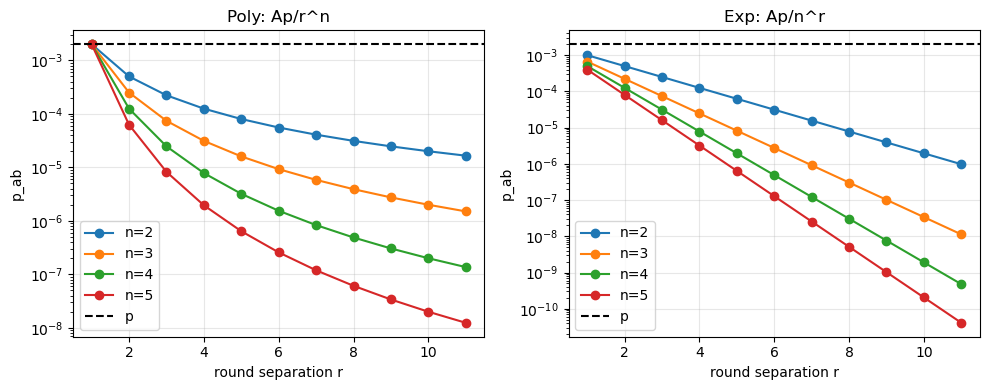

In [26]:
def poly_decay(r, A, p, n):
    """Polynomial decay: pair-correlation probability at round separation r."""
    return A * p / (r ** n)

def exp_decay(r, A, p, n):
    """Exponential decay: pair-correlation probability at round separation r."""
    return A * p / (n ** r)


r_vals = np.arange(1, 12)
p, A = 2e-3, 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for n in [2, 3, 4, 5]:
    ax1.plot(r_vals, poly_decay(r_vals, A, p, n), marker='o', label=f'n={n}')
    ax2.plot(r_vals, exp_decay(r_vals, A, p, n), marker='o', label=f'n={n}')
ax1.axhline(p, color='k', linestyle='--', label='p')
ax2.axhline(p, color='k', linestyle='--', label='p')
for ax, title in zip([ax1, ax2], ['Poly: Ap/r^n', 'Exp: Ap/n^r']):
    ax.set_yscale('log'); ax.set_xlabel('round separation r'); ax.set_ylabel('p_ab')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

---
## Part 5 — Round pairs and the pair probability vector

For `R` rounds, every pair `(a, b)` with `a < b` can be correlated.
There are `R*(R-1)/2` such pairs.

`get_round_pairs(R)` returns all pairs as a numpy array, ordered as:
```
(0,1), (0,2), (1,2), (0,3), (1,3), (2,3), ...
```
(all a's for each b, inner loop over a)

`calc_pair_probabilities(rounds)` evaluates the interaction function at the separation `r = b - a` for each pair, giving a 1D vector of probabilities.

In [27]:
def get_round_pairs(rounds):
    """
    Returns all pairs (a, b) with a < b, for rounds in range(rounds).
    Shape: (rounds*(rounds-1)//2, 2)
    """
    round_list = list(range(rounds))
    return np.array([(a, b) for i, b in enumerate(round_list) for a in round_list[:i]])

R = 6   # 6 syndrome rounds
pairs = get_round_pairs(R)
print(f'For R={R} rounds, there are {len(pairs)} pairs:')
print(pairs)

print()
print('Separation r = b - a for each pair:')
separations = pairs[:, 1] - pairs[:, 0]
print(separations)

For R=6 rounds, there are 15 pairs:
[[0 1]
 [0 2]
 [1 2]
 [0 3]
 [1 3]
 [2 3]
 [0 4]
 [1 4]
 [2 4]
 [3 4]
 [0 5]
 [1 5]
 [2 5]
 [3 5]
 [4 5]]

Separation r = b - a for each pair:
[1 2 1 3 2 1 4 3 2 1 5 4 3 2 1]


In [28]:
# Interaction function for LongTimePairPoly with A=1, p=2e-3, n=2
A_val, p_val, n_val = 1, 2e-3, 2
interaction_func = lambda r: poly_decay(r, A_val, p_val, n_val)

def calc_pair_probabilities(rounds, interaction_func):
    """
    For each pair (a,b), compute the correlated-error probability p_ab = interaction_func(b-a).
    Returns a 1D array of length rounds*(rounds-1)//2.
    """
    round_list = list(range(rounds))
    # separations for all pairs, in the same order as get_round_pairs
    separations = np.array([b - a for i, b in enumerate(round_list) for a in round_list[:i]])
    return interaction_func(separations)

probs = calc_pair_probabilities(R, interaction_func)
print('Pair correlation probabilities p_ab:')
for (a, b), r_sep, prob in zip(pairs, separations, probs):
    print(f'  pair ({a},{b}), sep={r_sep}: p_ab = {prob:.4e}')

Pair correlation probabilities p_ab:
  pair (0,1), sep=1: p_ab = 2.0000e-03
  pair (0,2), sep=2: p_ab = 5.0000e-04
  pair (1,2), sep=1: p_ab = 2.0000e-03
  pair (0,3), sep=3: p_ab = 2.2222e-04
  pair (1,3), sep=2: p_ab = 5.0000e-04
  pair (2,3), sep=1: p_ab = 2.0000e-03
  pair (0,4), sep=4: p_ab = 1.2500e-04
  pair (1,4), sep=3: p_ab = 2.2222e-04
  pair (2,4), sep=2: p_ab = 5.0000e-04
  pair (3,4), sep=1: p_ab = 2.0000e-03
  pair (0,5), sep=5: p_ab = 8.0000e-05
  pair (1,5), sep=4: p_ab = 1.2500e-04
  pair (2,5), sep=3: p_ab = 2.2222e-04
  pair (3,5), sep=2: p_ab = 5.0000e-04
  pair (4,5), sep=1: p_ab = 2.0000e-03


---
## Part 6 — The pair-to-qubit map (PAIRWISE model)

This is the core of the pairwise noise model.

We have `n_pairs` binary random variables (one per pair). Pair `(a, b)` fires with probability `p_ab`.
When it fires, it puts an error on **both** round `a` and round `b`.

The **pair-to-qubit map** is a binary matrix `M` of shape `(n_pairs, rounds)` where:
```
M[i, a] = 1   and   M[i, b] = 1   (only those two)
```
for the i-th pair `(a, b)`.

If `pair_fires` is a binary vector of length `n_pairs`,
then `pair_fires @ M` is a vector of length `rounds` counting how many pairs put an error on each round.
Taking mod 2 gives the net error (odd = error, even = no error).

In [29]:
def gen_pair_to_qubit_map_PAIRWISE(rounds):
    """
    Pairwise map: pair (a,b) sets columns a and b to 1.
    Shape: (n_pairs, rounds)
    """
    pairs = get_round_pairs(rounds)
    M = np.zeros((len(pairs), rounds), dtype=int)
    for i, (a, b) in enumerate(pairs):
        M[i, a] = 1
        M[i, b] = 1
    return M

M_pair = gen_pair_to_qubit_map_PAIRWISE(R)
print(f'Pair-to-qubit map M, shape {M_pair.shape}:')
print('Rows = pairs (a,b), Columns = rounds 0..5')
print(M_pair)
print()
# Each column j has a 1 for every pair that involves round j
print('Number of pairs involving each round:', M_pair.sum(axis=0))

Pair-to-qubit map M, shape (15, 6):
Rows = pairs (a,b), Columns = rounds 0..5
[[1 1 0 0 0 0]
 [1 0 1 0 0 0]
 [0 1 1 0 0 0]
 [1 0 0 1 0 0]
 [0 1 0 1 0 0]
 [0 0 1 1 0 0]
 [1 0 0 0 1 0]
 [0 1 0 0 1 0]
 [0 0 1 0 1 0]
 [0 0 0 1 1 0]
 [1 0 0 0 0 1]
 [0 1 0 0 0 1]
 [0 0 1 0 0 1]
 [0 0 0 1 0 1]
 [0 0 0 0 1 1]]

Number of pairs involving each round: [5 5 5 5 5 5]


---
## Part 7 — The pair-to-qubit map (STREAK model)

The streak model is identical to pairwise, **except** in how it builds the map.

Instead of only marking columns `a` and `b`, it marks **all** columns from `a` to `b` inclusive:
```
M[i, a:b+1] = 1
```
So a single pair-event now triggers errors across **every round in the streak** `[a, a+1, ..., b]`.
This is why streaky correlations are so much more damaging — one event corrupts many rounds.

Everything else (sampling, FlipSimulator loop, decoding) is exactly the same.

In [30]:
def gen_pair_to_qubit_map_STREAK(rounds):
    """
    Streak map: pair (a,b) sets ALL columns a, a+1, ..., b to 1.
    Shape: (n_pairs, rounds)
    """
    pairs = get_round_pairs(rounds)
    M = np.zeros((len(pairs), rounds), dtype=int)
    for i, (a, b) in enumerate(pairs):
        M[i, a:b+1] = 1    # <-- the only difference from pairwise
    return M

M_streak = gen_pair_to_qubit_map_STREAK(R)
print('Streak map:')
print(M_streak)
print()
print('Compare pairwise vs streak for pair (0, 3):')
pair_03_idx = [i for i, (a, b) in enumerate(pairs) if a == 0 and b == 3][0]
print(f'  Pairwise row: {M_pair[pair_03_idx]}')
print(f'  Streak   row: {M_streak[pair_03_idx]}')

Streak map:
[[1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [0 1 1 0 0 0]
 [1 1 1 1 0 0]
 [0 1 1 1 0 0]
 [0 0 1 1 0 0]
 [1 1 1 1 1 0]
 [0 1 1 1 1 0]
 [0 0 1 1 1 0]
 [0 0 0 1 1 0]
 [1 1 1 1 1 1]
 [0 1 1 1 1 1]
 [0 0 1 1 1 1]
 [0 0 0 1 1 1]
 [0 0 0 0 1 1]]

Compare pairwise vs streak for pair (0, 3):
  Pairwise row: [1 0 0 1 0 0]
  Streak   row: [1 1 1 1 0 0]


---
## Part 8 — Sampling errors from the pair model

Now we put it together: sample which pairs fire, then propagate to per-round qubit errors.

For efficiency, we simulate `batch_size` independent repetitions in parallel.

**Step by step:**
1. `pair_probabilities`: 1D array of length `n_pairs` — the probability each pair fires
2. Tile it: `(n_targets * batch_size, n_pairs)` — same probabilities for all (qubit, sample) combos
3. Draw uniform random numbers and compare: `pair_errors = rnd < pair_probabilities` → boolean
4. Matrix multiply by the map M: `qubit_errors = pair_errors @ M`
5. Reshape from `(n_targets * batch_size, rounds)` → `(batch_size, n_targets, rounds)` → transpose → `(rounds, n_targets, batch_size)`
6. Take mod 2 (odd number of pair events = net error)
7. Assign random Pauli type (X/Y/Z) to each error position
8. Expand into a full `(rounds, n_qubits, batch_size)` array (zeros for non-target qubits)

In [31]:
def sample_qubit_errors(targets, n_qubits, rounds, batch_size, interaction_func, gen_map_func):
    """
    Sample correlated qubit errors for `batch_size` parallel shots.

    Parameters
    ----------
    targets      : list of qubit indices that receive correlated errors
    n_qubits     : total number of qubits in the stim circuit
    rounds       : number of syndrome rounds
    batch_size   : number of independent shots to simulate in parallel
    interaction_func : f(r) → p_ab for round separation r
    gen_map_func : either gen_pair_to_qubit_map_PAIRWISE or _STREAK

    Returns
    -------
    qubit_errors : int array, shape (rounds, n_targets, batch_size)
                   values count how many pair events hit each (round, target, shot)
    """
    n_targets = len(targets)
    rng = np.random.default_rng()

    # Step 1: pair probabilities vector, length = n_pairs
    # For depolarizing, multiply by 16/15 (Stim's convention for two-qubit depolarizing)
    c = 16/15
    pair_probs = c * calc_pair_probabilities(rounds, interaction_func)

    # Step 2: tile across all (qubit, shot) combinations
    # shape: (n_targets * batch_size, n_pairs)
    pair_probs_matrix = np.tile(pair_probs, (n_targets * batch_size, 1))

    # Step 3: sample which pairs fire
    rnd = rng.random(pair_probs_matrix.shape)
    pair_errors = rnd < pair_probs_matrix   # bool, same shape

    # Step 4: propagate pair fires to round errors via the map
    M = gen_map_func(rounds)  # shape (n_pairs, rounds)
    # pair_errors @ M  has shape  (n_targets * batch_size, rounds)
    qubit_errors = np.matmul(pair_errors, M)

    # Step 5: reshape to (rounds, n_targets, batch_size)
    qubit_errors = qubit_errors.reshape(batch_size, n_targets, rounds).transpose(2, 1, 0)

    return qubit_errors


def sample_errors_depolarizing(qubit_errors, targets, n_qubits, rounds, batch_size):
    """
    Convert integer qubit_errors into X/Y/Z boolean error arrays.

    For depolarizing noise, each error position gets a random Pauli (X=1, Y=2, Z=3).
    An even number of pair-events on the same (round, qubit) cancels out (mod 2 = 0 = no error).

    Returns: (X_errors, Y_errors, Z_errors), each shape (rounds, n_qubits, batch_size)
    """
    rng = np.random.default_rng()

    # Booleanise: odd count → error, even count → no error
    has_error = qubit_errors.astype(bool)   # shape (rounds, n_targets, batch_size)

    # Assign random Pauli uniformly from {X=1, Y=2, Z=3}
    random_paulis = rng.integers(0, 3, size=has_error.shape, endpoint=True)
    # random_paulis * has_error: 0 where no error, 1/2/3 where error

    # Expand into full qubit space (n_qubits, not just n_targets)
    pauli_errors = np.zeros([rounds, n_qubits, batch_size], dtype=int)
    pauli_errors[:, targets, :] = random_paulis * has_error

    X_errors = pauli_errors == 1
    Y_errors = pauli_errors == 2
    Z_errors = pauli_errors == 3

    return X_errors, Y_errors, Z_errors


# Quick sanity check
targets = list(data_coords.keys())
n_qubits = circuit.num_qubits
batch_size = 100

qe = sample_qubit_errors(targets, n_qubits, rounds, batch_size, interaction_func, gen_pair_to_qubit_map_PAIRWISE)
X_err, Y_err, Z_err = sample_errors_depolarizing(qe, targets, n_qubits, rounds, batch_size)

print(f'qubit_errors shape: {qe.shape}  (rounds={rounds}, n_targets={len(targets)}, batch={batch_size})')
print(f'X_errors shape:     {X_err.shape}  (rounds, n_qubits={n_qubits}, batch)')
print(f'Mean error rate across all positions: {X_err.mean():.4f} (should be ~p/3={p_val/3:.4f})')

qubit_errors shape: (6, 9, 100)  (rounds=6, n_targets=9, batch=100)
X_errors shape:     (6, 26, 100)  (rounds, n_qubits=26, batch)
Mean error rate across all positions: 0.0005 (should be ~p/3=0.0007)


---
## Part 9 — Running the circuit: `stim.FlipSimulator` and `broadcast_pauli_errors`

**`stim.FlipSimulator`** simulates `batch_size` copies of a circuit in parallel using a stabilizer tableau.
It tracks which qubits have Pauli flips applied.

**`broadcast_pauli_errors(pauli, mask)`** injects errors from a boolean array `mask` of shape `(n_qubits, batch_size)`.
If `mask[q, s] = True`, it applies that Pauli to qubit `q` in shot `s`.

**The simulation loop:**
```
sim.do(circuit_init)              # RESET + TICK
inject errors for round 0         # broadcast_pauli_errors
sim.do(circuit_init_round)        # first syndrome round gates
for j in range(1, rounds):
    inject errors for round j
    sim.do(circuit_repeat_block)
sim.do(circuit_final)
```

After simulation:
- `sim.get_detector_flips()` — shape `(n_detectors, batch_size)` — 1 where a detector measured an unexpected parity
- `sim.get_observable_flips()` — shape `(n_observables, batch_size)` — 1 where the logical qubit was flipped

In [32]:
def run_circuit_with_correlated_noise(split_circuits, X_errors, Y_errors, Z_errors, rounds, batch_size):
    """
    Run a split stim circuit with pre-sampled depolarizing errors using FlipSimulator.

    Parameters
    ----------
    split_circuits : (circuit_init, circuit_init_round, circuit_repeat_block, circuit_final)
    X_errors, Y_errors, Z_errors : bool arrays shape (rounds, n_qubits, batch_size)
    rounds     : total syndrome rounds
    batch_size : number of parallel shots

    Returns
    -------
    detection_events : shape (batch_size, n_detectors) — syndrome measurements
    observable_flips : shape (batch_size,) — did the logical qubit flip?
    """
    circuit_init, circuit_init_round, circuit_repeat_block, circuit_final = split_circuits

    sim = stim.FlipSimulator(batch_size=batch_size)

    # Round 0
    sim.do(circuit_init)
    sim.broadcast_pauli_errors(pauli='X', mask=X_errors[0])   # inject X errors for round 0
    sim.broadcast_pauli_errors(pauli='Y', mask=Y_errors[0])   # inject Y errors for round 0
    sim.broadcast_pauli_errors(pauli='Z', mask=Z_errors[0])   # inject Z errors for round 0
    sim.do(circuit_init_round)                                 # run the first syndrome round

    # Rounds 1 .. rounds-1
    for j in range(1, rounds):
        sim.broadcast_pauli_errors(pauli='X', mask=X_errors[j])
        sim.broadcast_pauli_errors(pauli='Y', mask=Y_errors[j])
        sim.broadcast_pauli_errors(pauli='Z', mask=Z_errors[j])
        sim.do(circuit_repeat_block)

    sim.do(circuit_final)   # final data-qubit measurement + observable

    # Collect results
    # get_detector_flips() returns (n_detectors, batch_size); transpose to (batch_size, n_detectors)
    detection_events = sim.get_detector_flips().transpose()
    observable_flips = sim.get_observable_flips().flatten()   # shape (batch_size,)

    return detection_events, observable_flips


# Test it
detection_events, observable_flips = run_circuit_with_correlated_noise(
    split_circuits, X_err, Y_err, Z_err, rounds, batch_size
)
print(f'detection_events shape: {detection_events.shape}  (batch, detectors)')
print(f'observable_flips shape: {observable_flips.shape}  (batch,)')
print(f'Logical error rate (raw, before decoding): {observable_flips.mean():.3f}')

detection_events shape: (100, 48)  (batch, detectors)
observable_flips shape: (100,)  (batch,)
Logical error rate (raw, before decoding): 0.020


---
## Part 10 — Decoding with pymatching

**Why decode?** The syndrome detector flips tell us that *something* went wrong, but not exactly where.
The decoder's job is to look at the detector flips and guess the most likely correction.
If the correction disagrees with what actually happened to the logical qubit → logical error.

**Minimum-weight perfect matching (MWPM)** is a standard decoder for surface codes.
We use `pymatching.Matching.from_detector_error_model(dem)` to build the decoder.

**The detector error model (DEM)** describes the graphical structure needed for MWPM.
We build it from the *marginalised* (independent) version of the circuit — same marginal error rates,
but without temporal correlations. This is the standard approach and is equivalent to decoding with
an approximation that ignores correlations (which is fine — we're measuring how much correlations hurt).

**How to get the marginalised circuit:** Replace the correlated pair probabilities with their
single-round average (marginal). Round `i` gets an error rate equal to the probability of an error
in round `i` after averaging over all pair interactions.

**Marginal formula for pairwise (X/Z errors):**
$$p_{\text{marginal}, i} = \frac{1}{2}\left(1 - \prod_{j \neq i}(1 - 2p_{ij})\right)$$
This accounts for the fact that an odd number of pair events involving round `i` gives a net error.

In [33]:
def get_round_pair_distances(rounds):
    """
    For each round i, return a 1D array of the separations |i - j| for all j != i.
    Used to compute which pair probabilities involve round i.

    Returns a matrix of shape (ceil(rounds/2), rounds-1).
    Row i contains the pair-separations for round i (and rounds-1-i by symmetry).
    """
    size = int(np.ceil(0.5 * rounds))
    round_pair_distances = np.zeros((size, rounds - 1))
    for i in range(rounds - 1):
        np.fill_diagonal(round_pair_distances[:, i:], i + 1)
        np.fill_diagonal(round_pair_distances[i + 1:, :], i + 1)
    return round_pair_distances


def calc_marginals_pauli(probabilities):
    """
    For pairwise X/Z errors: the marginal (single-round) error rate.
    Given a list of pair-interaction probabilities p_ij for all j paired with round i:
      p_marginal = 0.5 * (1 - prod(1 - 2*p_ij))
    """
    t_l = np.prod(1 - (2 * np.array(probabilities)))
    return 0.5 * (1 - t_l)


def calc_marginals_per_round_pairwise_pauli(rounds, interaction_func):
    """
    Compute the marginal error rate for each round under the pairwise model.

    For each round i, collect the pair-interaction probabilities for all pairs (i, j),
    then compute the marginal using calc_marginals_pauli.
    By symmetry, round i and round (rounds-1-i) have the same marginal.
    """
    marginals = np.zeros(rounds)
    # round_pair_distances[i, :] = separations |i - j| for all j != i, for the first ceil(R/2) rounds
    round_pair_distances = get_round_pair_distances(rounds)         # shape (ceil(R/2), R-1)
    round_pair_probs     = interaction_func(round_pair_distances)   # same shape

    for i in range(round_pair_probs.shape[0]):
        p = calc_marginals_pauli(round_pair_probs[i, :])
        marginals[i]       = p
        marginals[-i - 1]  = p   # symmetric: round R-1-i has the same marginal

    return marginals


marginals = calc_marginals_per_round_pairwise_pauli(rounds, interaction_func)
print('Marginal error rate per round (should be close to p =', p_val, '):')
for i, m in enumerate(marginals):
    print(f'  round {i}: {m:.4e}')

Marginal error rate per round (should be close to p = 0.002 ):
  round 0: 2.9230e-03
  round 1: 4.8321e-03
  round 2: 5.2035e-03
  round 3: 5.2035e-03
  round 4: 4.8321e-03
  round 5: 2.9230e-03


In [34]:
def build_marginalised_circuit(circuit, targets, marginals, error_type='DEPOLARIZE1'):
    """
    Build a version of the circuit where correlated noise is replaced by independent noise
    at the marginal error rates. Used to construct the DEM for decoding.

    Parameters
    ----------
    circuit    : original stim.Circuit (without noise)
    targets    : list of qubit indices to apply noise to
    marginals  : array of per-round marginal error rates
    error_type : stim instruction name, e.g. 'DEPOLARIZE1' or 'X_ERROR'

    Returns
    -------
    stim.Circuit with independent per-round noise inserted
    """
    (circuit_init, circuit_init_round,
     circuit_repeat_block, circuit_final), repeat_count = split_circuit(circuit)
    rounds_local = repeat_count + 1

    out = stim.Circuit()
    out += circuit_init

    # Round 0: inject noise, then run the first syndrome round
    out.append(error_type, targets, marginals[0])
    out += circuit_init_round

    # Rounds 1 .. rounds-1
    for i in range(1, rounds_local):
        out.append(error_type, targets, marginals[i])
        out += circuit_repeat_block

    out += circuit_final
    return out


marginalised = build_marginalised_circuit(circuit, targets, marginals, error_type='DEPOLARIZE1')
dem = marginalised.detector_error_model()
matcher = pymatching.Matching.from_detector_error_model(dem)
print('Decoder built from marginalised circuit DEM.')
print(f'Number of detectors: {marginalised.num_detectors}')

Decoder built from marginalised circuit DEM.
Number of detectors: 48


---
## Part 11 — Putting it all together: `sample_logical_error_rate`

The full workflow for one repetition:
1. Sample correlated errors → X/Y/Z error arrays
2. Run the circuit via FlipSimulator with those errors
3. Decode the detector flips with MWPM
4. Compare decoder predictions with actual observable flips → count errors

Repeat `repetitions` times, accumulate shots and errors.

In [35]:
def sample_logical_error_rate_pairwise(
    circuit, interaction_func, repetitions, batch_size, return_error_rate=True
):
    """
    Estimate the logical error rate of a surface-code circuit under pairwise-correlated
    depolarizing noise on data qubits.

    Parameters
    ----------
    circuit          : stim.Circuit (the surface code, without noise)
    interaction_func : f(r) → p_ab
    repetitions      : how many times to repeat the sampling loop
    batch_size       : shots per repetition
    return_error_rate: if True return mean error rate; if False return (total_shots, total_errors)

    Returns
    -------
    float or (int, int)
    """
    # Setup (done once)
    split_circs, repeat_count = split_circuit(circuit)
    n_rounds = repeat_count + 1
    n_qubits = circuit.num_qubits

    data_coords, _ = get_partitioned_qubit_coords(circuit)
    targets = list(data_coords.keys())

    # Build decoder from marginalised circuit
    marginals = calc_marginals_per_round_pairwise_pauli(n_rounds, interaction_func)
    # For depolarizing noise, marginals need a slight rescale (16/15 factor already in sampling)
    # but the marginalised circuit uses DEPOLARIZE1 — use marginals directly here
    marg_circuit = build_marginalised_circuit(circuit, targets, marginals, 'DEPOLARIZE1')
    dem = marg_circuit.detector_error_model()
    matcher = pymatching.Matching.from_detector_error_model(dem)

    total_errors = 0
    sampled_rates = []

    for i in range(repetitions):
        # 1. Sample errors
        qe = sample_qubit_errors(targets, n_qubits, n_rounds, batch_size,
                                  interaction_func, gen_pair_to_qubit_map_PAIRWISE)
        X_err, Y_err, Z_err = sample_errors_depolarizing(qe, targets, n_qubits, n_rounds, batch_size)

        # 2. Run circuit
        det_events, obs_flips = run_circuit_with_correlated_noise(
            split_circs, X_err, Y_err, Z_err, n_rounds, batch_size
        )

        # 3. Decode
        predictions = matcher.decode_batch(det_events).flatten()

        # 4. Count errors
        n_errors = int(np.sum(predictions != obs_flips))
        total_errors += n_errors
        sampled_rates.append(n_errors / batch_size)

    if return_error_rate:
        return float(np.mean(sampled_rates))
    else:
        return int(batch_size * repetitions), total_errors


# Run a small demo
shots, errors = sample_logical_error_rate_pairwise(
    circuit,
    interaction_func,
    repetitions=5,
    batch_size=500,
    return_error_rate=False,
)
print(f'shots={shots}, errors={errors}, logical error rate ≈ {errors/shots:.4f}')

shots=2500, errors=12, logical error rate ≈ 0.0048


---
## Part 12 — Converting shots to per-round logical error rate

The raw `errors/shots` gives the probability of a logical error **per circuit run** (across all `r` rounds).
To compare across different code distances (which use `r = 2d` rounds), we need the error rate **per round**.

If each round independently contributes with probability `q`, then the per-circuit rate is:
$$p_{\text{shot}} = \frac{1}{2}\left(1 - (1 - 2q)^r\right)$$
Inverting:
$$q = \frac{1}{2}\left(1 - (1 - 2 p_{\text{shot}})^{1/r}\right)$$

We also compute a 95% confidence interval using a normal approximation on `p_shot`.

In [36]:
def calc_per_round(per_shot, rounds):
    """Convert per-circuit error rate to per-round error rate."""
    if per_shot >= 0.5:
        per_shot = 1 - per_shot   # handle the > 0.5 edge case gracefully
    return 0.5 * (1 - (1 - 2 * per_shot) ** (1 / rounds))


def calc_per_round_ci(errors, shots, rounds, confidence=0.95):
    """
    Compute per-round error rate with a 95% confidence interval.

    Returns: (per_round, lower_half_width, upper_half_width)
    """
    per_shot  = errors / shots
    per_round = calc_per_round(per_shot, rounds)

    # Normal approximation for a binomial proportion
    se = np.sqrt(per_shot * (1 - per_shot) / shots)
    z  = norm.ppf(0.975)       # 1.96 for 95% CI
    me = z * se                # margin of error on per_shot

    lower = per_round - calc_per_round(per_shot - me, rounds)
    upper = calc_per_round(per_shot + me, rounds) - per_round

    return per_round, lower, upper


per_round, ci_lo, ci_hi = calc_per_round_ci(errors, shots, rounds)
print(f'Per-shot error rate : {errors/shots:.4f}')
print(f'Per-round error rate: {per_round:.4e}')
print(f'95% CI              : [{per_round - ci_lo:.4e}, {per_round + ci_hi:.4e}]')

Per-shot error rate : 0.0048
Per-round error rate: 8.0322e-04
95% CI              : [3.4906e-04, 1.2595e-03]


---
## Part 13 — Streak model: the only difference

To switch from pairwise to streak, we just swap out `gen_pair_to_qubit_map_PAIRWISE` for
`gen_pair_to_qubit_map_STREAK`. Everything else — sampling random pair fires, matrix multiply,
FlipSimulator loop, decoding — is identical.

One subtle difference: the streak model's marginalised rates have extra terms.
For a streak event `(a, b)`, every round `k` in `[a, b]` gets an error, not just `a` and `b`.
So the marginal for round `i` must sum over all streak events that include `i`:
- all pairs `(a, b)` with `a ≤ i ≤ b`

The streak model also uses a different `int_to_bool_errors`: instead of taking mod 2 (deterministic),
it treats each streak event as a 50/50 chance of actually causing an error (random bit × streak fire).
This keeps the marginal rate consistent.

In [37]:
def sample_qubit_errors_STREAK(targets, n_qubits, rounds, batch_size, interaction_func):
    """
    Streak version: same as pairwise, but:
    1. Uses the streak pair-to-qubit map (all rounds in [a,b] fire)
    2. Each streak event has a 50% chance of actually causing an error (random bit)
    """
    n_targets = len(targets)
    rng = np.random.default_rng()

    pair_probs = calc_pair_probabilities(rounds, interaction_func)  # no 16/15 factor for streak
    pair_probs_matrix = np.tile(pair_probs, (n_targets * batch_size, 1))

    rnd = rng.random(pair_probs_matrix.shape)
    pair_errors = rnd < pair_probs_matrix

    M = gen_pair_to_qubit_map_STREAK(rounds)
    qubit_errors = np.matmul(pair_errors, M)
    qubit_errors = qubit_errors.reshape(batch_size, n_targets, rounds).transpose(2, 1, 0)

    # Streak: a fire at (a,b) MIGHT cause an error in each of rounds a..b with prob 0.5
    streak_fires = qubit_errors.astype(bool)
    random_bits  = rng.integers(0, 1, size=streak_fires.shape, endpoint=True)
    qubit_errors = random_bits * streak_fires   # 0 or 1

    return qubit_errors


# Quick comparison: pairwise vs streak error density
qe_pair   = sample_qubit_errors(targets, n_qubits, rounds, 1000, interaction_func,
                                  gen_pair_to_qubit_map_PAIRWISE)
qe_streak = sample_qubit_errors_STREAK(targets, n_qubits, rounds, 1000, interaction_func)

print(f'Pairwise: mean qubit errors per (round, shot) = {np.mod(qe_pair, 2).mean():.4f}')
print(f'Streak  : mean qubit errors per (round, shot) = {qe_streak.mean():.4f}')
print(f'Both should be near p = {p_val:.4f}')

Pairwise: mean qubit errors per (round, shot) = 0.0044
Streak  : mean qubit errors per (round, shot) = 0.0027
Both should be near p = 0.0020


---
## Part 14 — Syndrome qubit errors (Class 1, `LongTimePairMPoly`)

**Why is this different?** Syndrome (ancilla) qubits are measured at the *end* of each round.
An error on a syndrome qubit right *before* its measurement flips the measurement outcome.
This is modeled as an `X_ERROR` on the syndrome qubit inserted *just before* the `MR` gate.

To achieve this we need to split the circuit differently:
`split_circuit_measurements` cuts each round at the `MR` instruction:
- Part 1: all gates before `MR` (H, CX gates)
- Part 2: the `MR` and everything after it (DETECTOR, SHIFT_COORDS etc.)

The simulation loop then becomes:
```
run_part1(round j)       # H + CX gates
inject X errors           # right before MR
run_part2(round j)       # MR + DETECTOR
```

In [38]:
def split_circuit_measurements(circuit):
    """
    Split a round's circuit at the MR (measure-and-reset) instruction.
    Returns (before_measure, at_measure_and_after).
    """
    for i, instr in enumerate(circuit):
        if instr.name in ('MR', 'M'):
            i_split = i
            break
    return circuit[:i_split], circuit[i_split:]


# Apply this to the init_round and repeat_block
init_round_parts  = split_circuit_measurements(circuit_init_round)
repeat_block_parts = split_circuit_measurements(circuit_repeat_block)

print('--- circuit_init_round BEFORE MR ---')
print(init_round_parts[0])
print()
print('--- circuit_init_round AT+AFTER MR ---')
print(init_round_parts[1])

--- circuit_init_round BEFORE MR ---
H 2 11 16 25
TICK
CX 2 3 16 17 11 12 15 14 10 9 19 18
TICK
CX 2 1 16 15 11 10 8 14 3 9 12 18
TICK
CX 16 10 11 5 25 19 8 9 17 18 12 13
TICK
CX 16 8 11 3 25 17 1 9 10 18 5 13
TICK
H 2 11 16 25
TICK

--- circuit_init_round AT+AFTER MR ---
MR 2 9 11 13 14 16 18 25
DETECTOR(0, 4, 0) rec[-4]
DETECTOR(2, 2, 0) rec[-7]
DETECTOR(4, 4, 0) rec[-2]
DETECTOR(6, 2, 0) rec[-5]


In [39]:
def run_circuit_syndrome_qubit_errors(
    circuit_init,
    circuit_init_round_parts,   # (before_MR, at_MR_and_after)
    circuit_repeat_block_parts, # (before_MR, at_MR_and_after)
    circuit_final,
    X_errors,                   # shape (rounds, n_qubits, batch_size) — X errors on syndrome qubits
    rounds,
    batch_size,
):
    """
    Run the circuit with X errors injected just before each round's syndrome measurement.
    This models measurement bit-flip errors on the syndrome qubits.
    """
    sim = stim.FlipSimulator(batch_size=batch_size)

    sim.do(circuit_init)

    # Round 0
    sim.do(circuit_init_round_parts[0])               # H + CX gates
    sim.broadcast_pauli_errors(pauli='X', mask=X_errors[0])  # inject X before MR
    sim.do(circuit_init_round_parts[1])               # MR + DETECTOR

    # Rounds 1 .. rounds-1
    for j in range(1, rounds):
        sim.do(circuit_repeat_block_parts[0])
        sim.broadcast_pauli_errors(pauli='X', mask=X_errors[j])
        sim.do(circuit_repeat_block_parts[1])

    sim.do(circuit_final)

    detection_events = sim.get_detector_flips().transpose()
    observable_flips = sim.get_observable_flips().flatten()
    return detection_events, observable_flips


# Test: sample X errors on syndrome qubits
syndrome_targets = list(syndrome_coords.keys())

qe_m = sample_qubit_errors(syndrome_targets, n_qubits, rounds, batch_size,
                             interaction_func, gen_pair_to_qubit_map_PAIRWISE)

# For syndrome errors we use plain X_ERROR (not depolarizing)
has_error_m = np.mod(qe_m, 2).astype(bool)   # mod 2 for pairwise
X_errors_m  = np.zeros([rounds, n_qubits, batch_size], dtype=bool)
X_errors_m[:, syndrome_targets, :] = has_error_m

det_m, obs_m = run_circuit_syndrome_qubit_errors(
    circuit_init, init_round_parts, repeat_block_parts,
    circuit_final, X_errors_m, rounds, batch_size
)
print(f'Syndrome-error detection_events shape: {det_m.shape}')
print(f'Logical error rate (raw): {obs_m.mean():.3f}')

Syndrome-error detection_events shape: (100, 48)
Logical error rate (raw): 0.000


---
## Part 15 — Two-qubit gate errors (Class 2, `LongTimePairCPoly`)

Class 2 targets the **CX (CNOT) gates** between data and syndrome qubits.
There are **4 layers** of CX gates per syndrome round (one for each cardinal direction in the
rotated surface code).

`split_circuit_cx` cuts the circuit after each CX layer:
- Pieces 0..3: each one ends just after a CX layer
- Piece 4: everything after the last CX (the measurement)

For each CX layer, we sample correlated depolarizing errors on the **control qubits**,
and apply them to both the control and target qubit of each gate.

Note `A=0.5` is used for Class 2 (vs `A=1` for Classes 0 and 1) to account for the
two-qubit nature of the errors.

In [40]:
def split_circuit_cx(circuit):
    """
    Split a round's circuit at each CX gate, returning a list of sub-circuits.
    The i-th sub-circuit contains everything up to and including the i-th CX layer.
    The last sub-circuit contains everything after the final CX.
    """
    circuits = []
    i_split_prev = 0
    for i, instr in enumerate(circuit):
        if instr.name == 'CX':
            i_split = i + 1
            circuits.append(circuit[i_split_prev:i_split])
            i_split_prev = i_split
    circuits.append(circuit[i_split_prev:])
    return circuits


def get_control_qubits(circuit):
    """
    Return the list of (control, target) pairs for each CX layer in the circuit.
    Returns a list of lists: [[q0_ctrl, q0_tgt, q1_ctrl, q1_tgt, ...], ...]  (flat pairs)
    """
    control_qubits = []
    for instr in circuit:
        if instr.name == 'CX':
            control_qubits.append([q.value for q in instr.targets_copy()])
    return control_qubits


cx_layers_init   = split_circuit_cx(circuit_init_round)
cx_layers_repeat = split_circuit_cx(circuit_repeat_block)
cx_targets       = get_control_qubits(circuit_repeat_block)

print(f'Number of CX layers per round: {len(cx_targets)}')
for i, layer in enumerate(cx_targets):
    ctrls = layer[::2]
    tgts  = layer[1::2]
    print(f'  CX layer {i}: ctrl qubits={ctrls}, tgt qubits={tgts}')

Number of CX layers per round: 4
  CX layer 0: ctrl qubits=[2, 16, 11, 15, 10, 19], tgt qubits=[3, 17, 12, 14, 9, 18]
  CX layer 1: ctrl qubits=[2, 16, 11, 8, 3, 12], tgt qubits=[1, 15, 10, 14, 9, 18]
  CX layer 2: ctrl qubits=[16, 11, 25, 8, 17, 12], tgt qubits=[10, 5, 19, 9, 18, 13]
  CX layer 3: ctrl qubits=[16, 11, 25, 1, 10, 5], tgt qubits=[8, 3, 17, 9, 18, 13]


---
## Part 16 — Full minimal simulation: distance sweep

Now let's compare pairwise correlated vs independent noise over a few code distances.
We use the `LongTimePairPoly` model (data qubits, polynomial decay).

**This is a toy run** — the paper uses `max_shots=10M` and `num_workers=12`.
Here we use `batch_size=500` × `repetitions=5` = 2500 shots, just to see the trend.

In [41]:
distances  = [3, 5, 7]
p_base     = 2e-3
A_val, n_val = 1, 2
batch_sz   = 500
reps       = 5

results_corr  = {}   # {d: (per_round, ci_lo, ci_hi)}
results_indep = {}

for d in distances:
    r_rounds = d * 2
    circ = stim.Circuit.generated('surface_code:rotated_memory_z', rounds=r_rounds, distance=d)

    interact = lambda r: poly_decay(r, A_val, p_base, n_val)

    # --- Correlated ---
    shots_c, errs_c = sample_logical_error_rate_pairwise(
        circ, interact, repetitions=reps, batch_size=batch_sz, return_error_rate=False
    )
    if errs_c > 0:
        results_corr[d] = calc_per_round_ci(errs_c, shots_c, r_rounds)

    # --- Independent (marginalised, use sinter-style via stim sampler) ---
    split_c, rc = split_circuit(circ)
    n_rds = rc + 1
    d_coords, _ = get_partitioned_qubit_coords(circ)
    tgts = list(d_coords.keys())
    margs = calc_marginals_per_round_pairwise_pauli(n_rds, interact)
    marg_circ = build_marginalised_circuit(circ, tgts, margs, 'DEPOLARIZE1')

    sampler = marg_circ.compile_detector_sampler()
    dem_i   = marg_circ.detector_error_model()
    match_i = pymatching.Matching.from_detector_error_model(dem_i)

    total_shots_i = batch_sz * reps
    det_i, obs_i  = sampler.sample(shots=total_shots_i, separate_observables=True)
    preds_i       = match_i.decode_batch(det_i).flatten()
    errs_i        = int(np.sum(preds_i != obs_i.flatten()))

    if errs_i > 0:
        results_indep[d] = calc_per_round_ci(errs_i, total_shots_i, r_rounds)

    print(f'd={d}: corr errors={errs_c}/{shots_c}, indep errors={errs_i}/{total_shots_i}')

print()
print('Correlated per-round error rates:')
for d, (rate, lo, hi) in results_corr.items():
    print(f'  d={d}: {rate:.3e}  [{rate-lo:.3e}, {rate+hi:.3e}]')
print()
print('Independent per-round error rates:')
for d, (rate, lo, hi) in results_indep.items():
    print(f'  d={d}: {rate:.3e}  [{rate-lo:.3e}, {rate+hi:.3e}]')

d=3: corr errors=8/2500, indep errors=22/2500
d=5: corr errors=0/2500, indep errors=0/2500
d=7: corr errors=0/2500, indep errors=0/2500

Correlated per-round error rates:
  d=3: 5.348e-04  [1.645e-04, 9.064e-04]

Independent per-round error rates:
  d=3: 1.478e-03  [8.602e-04, 2.099e-03]


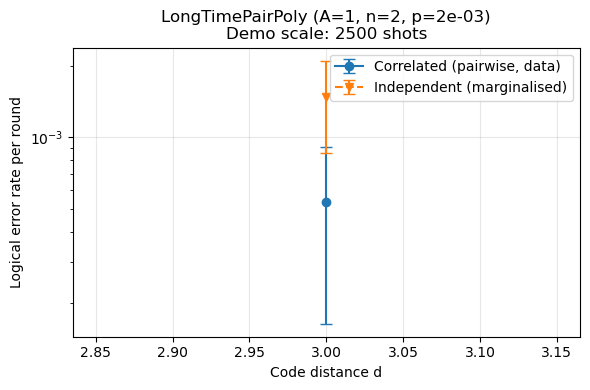

In [42]:
if results_corr and results_indep:
    fig, ax = plt.subplots(figsize=(6, 4))

    ds_c = sorted(results_corr.keys())
    ys_c = [results_corr[d][0] for d in ds_c]
    eye_c = np.array([[results_corr[d][1], results_corr[d][2]] for d in ds_c]).T

    ds_i = sorted(results_indep.keys())
    ys_i = [results_indep[d][0] for d in ds_i]
    eye_i = np.array([[results_indep[d][1], results_indep[d][2]] for d in ds_i]).T

    ax.errorbar(ds_c, ys_c, yerr=eye_c, fmt='o-', label='Correlated (pairwise, data)', capsize=4)
    ax.errorbar(ds_i, ys_i, yerr=eye_i, fmt='v--', label='Independent (marginalised)', capsize=4)

    ax.semilogy()
    ax.set_xlabel('Code distance d')
    ax.set_ylabel('Logical error rate per round')
    ax.set_title(f'LongTimePairPoly (A={A_val}, n={n_val}, p={p_base:.0e})\nDemo scale: {batch_sz*reps} shots')
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print('Not enough errors observed — try increasing batch_sz or reps.')

---
## Part 17 — Pairwise vs Streak: distance sweep comparison

The only code change between pairwise and streak is swapping `gen_pair_to_qubit_map_PAIRWISE`
for `gen_pair_to_qubit_map_STREAK`. Everything else — the FlipSimulator loop, decoding, statistics — is identical.

We run both models and compare:
- **Pairwise correlated** — a pair-event affects only rounds `a` and `b`
- **Streak correlated** — a pair-event affects all rounds `a, a+1, ..., b`
- **Independent** — marginalised rates, no temporal correlations (baseline)

Expected result from the paper: pairwise ≈ independent (both decay **exponentially** with distance `d`), while streak decays much more slowly (approximately as a **power law** `d^b`). This is the central finding.

In [43]:
def sample_logical_error_rate_generic(circuit, interaction_func, gen_map_func, repetitions, batch_size):
    """
    Estimate logical error rate using any pair-to-qubit map (pairwise OR streak).
    The only difference between the two models is `gen_map_func`.
    """
    split_circs, repeat_count = split_circuit(circuit)
    n_rounds  = repeat_count + 1
    n_qubits  = circuit.num_qubits
    d_coords, _ = get_partitioned_qubit_coords(circuit)
    targets   = list(d_coords.keys())

    marginals    = calc_marginals_per_round_pairwise_pauli(n_rounds, interaction_func)
    marg_circuit = build_marginalised_circuit(circuit, targets, marginals, 'DEPOLARIZE1')
    dem          = marg_circuit.detector_error_model()
    matcher      = pymatching.Matching.from_detector_error_model(dem)

    total_errors = 0
    for _ in range(repetitions):
        qe = sample_qubit_errors(targets, n_qubits, n_rounds, batch_size,
                                  interaction_func, gen_map_func)
        X_err, Y_err, Z_err = sample_errors_depolarizing(
            qe, targets, n_qubits, n_rounds, batch_size
        )
        det_ev, obs_fl = run_circuit_with_correlated_noise(
            split_circs, X_err, Y_err, Z_err, n_rounds, batch_size
        )
        preds = matcher.decode_batch(det_ev).flatten()
        total_errors += int(np.sum(preds != obs_fl))

    return int(batch_size * repetitions), total_errors


# ── Parameters ────────────────────────────────────────────────────────────────
distances = [3, 5, 7]
p_base    = 2e-3
A_val, n_val = 1, 2
batch_sz  = 500
reps      = 8
interact  = lambda r: poly_decay(r, A_val, p_base, n_val)
# ──────────────────────────────────────────────────────────────────────────────

res_pair   = {}   # {d: (per_round, ci_lo, ci_hi)}
res_streak = {}
res_indep  = {}

for d in distances:
    r_rounds = d * 2
    circ = stim.Circuit.generated('surface_code:rotated_memory_z', rounds=r_rounds, distance=d)

    # Pairwise correlated
    sh_p, er_p = sample_logical_error_rate_generic(
        circ, interact, gen_pair_to_qubit_map_PAIRWISE, reps, batch_sz
    )
    if er_p > 0:
        res_pair[d] = calc_per_round_ci(er_p, sh_p, r_rounds)

    # Streak correlated
    sh_s, er_s = sample_logical_error_rate_generic(
        circ, interact, gen_pair_to_qubit_map_STREAK, reps, batch_sz
    )
    if er_s > 0:
        res_streak[d] = calc_per_round_ci(er_s, sh_s, r_rounds)

    # Independent: sample directly from the marginalised stim circuit
    split_c, rc = split_circuit(circ)
    n_rds = rc + 1
    d_c, _ = get_partitioned_qubit_coords(circ)
    tgts   = list(d_c.keys())
    margs  = calc_marginals_per_round_pairwise_pauli(n_rds, interact)
    marg_c = build_marginalised_circuit(circ, tgts, margs, 'DEPOLARIZE1')
    sampler  = marg_c.compile_detector_sampler()
    match_i  = pymatching.Matching.from_detector_error_model(marg_c.detector_error_model())
    total_sh = batch_sz * reps
    det_i, obs_i = sampler.sample(shots=total_sh, separate_observables=True)
    er_i = int(np.sum(match_i.decode_batch(det_i).flatten() != obs_i.flatten()))
    if er_i > 0:
        res_indep[d] = calc_per_round_ci(er_i, total_sh, r_rounds)

    print(f'd={d}: pairwise={er_p}/{sh_p}  streak={er_s}/{sh_s}  indep={er_i}/{total_sh}')

print('Done.')

d=3: pairwise=23/4000  streak=27/4000  indep=31/4000
d=5: pairwise=0/4000  streak=2/4000  indep=0/4000
d=7: pairwise=0/4000  streak=0/4000  indep=0/4000
Done.


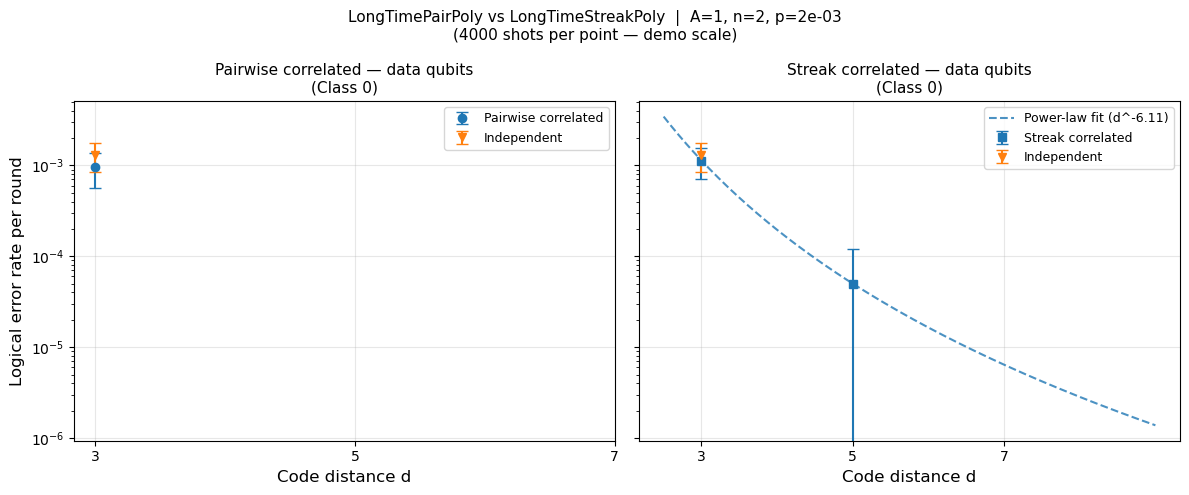


Key observation:
  Pairwise: correlated ≈ independent. Both slopes similar → same exponential decay with d.
  Streak:   correlated has a SHALLOWER slope than independent → power-law decay, not exponential.
  ⇒ Streak correlations degrade QEC much more than pairwise correlations.


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
c_corr, c_indep = colors[0], colors[1]
e = np.e
x_fit = np.linspace(2.5, 9, 200)

def extract(res):
    ds = sorted(res.keys())
    ys = np.array([res[d][0] for d in ds])
    ye = np.array([[res[d][1], res[d][2]] for d in ds]).T
    return np.array(ds, dtype=float), ys, ye

# ── Left panel: Pairwise ────────────────────────────────────────────────────
ax = axes[0]
if res_pair:
    ds, ys, ye = extract(res_pair)
    ax.errorbar(ds, ys, yerr=ye, fmt='o', color=c_corr, capsize=4,
                markersize=6, label='Pairwise correlated')
    if len(ds) >= 2:
        # Pairwise correlated decays exponentially like independent noise
        coeffs = np.polyfit(ds, np.log(ys), 1)
        ax.plot(x_fit, e**np.polyval(coeffs, x_fit), color=c_corr,
                linestyle='--', alpha=0.8,
                label=f'Exp fit (slope {coeffs[0]:.2f} per d)')

if res_indep:
    ds_i, ys_i, ye_i = extract(res_indep)
    ax.errorbar(ds_i, ys_i, yerr=ye_i, fmt='v', color=c_indep, capsize=4,
                markersize=6, label='Independent')
    if len(ds_i) >= 2:
        coeffs_i = np.polyfit(ds_i, np.log(ys_i), 1)
        ax.plot(x_fit, e**np.polyval(coeffs_i, x_fit), color=c_indep,
                linestyle=':', alpha=0.8,
                label=f'Exp fit (slope {coeffs_i[0]:.2f} per d)')

ax.set_yscale('log')
ax.set_xlabel('Code distance d', fontsize=12)
ax.set_ylabel('Logical error rate per round', fontsize=12)
ax.set_title('Pairwise correlated — data qubits\n(Class 0)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(distances)

# ── Right panel: Streak ─────────────────────────────────────────────────────
ax = axes[1]
if res_streak:
    ds, ys, ye = extract(res_streak)
    ax.errorbar(ds, ys, yerr=ye, fmt='s', color=c_corr, capsize=4,
                markersize=6, label='Streak correlated')
    if len(ds) >= 2:
        # Streak correlated decays as a POWER LAW:  y ~ d^b
        # log(y) = b*log(d) + const  →  fit in log-log space
        coeffs = np.polyfit(np.log(ds), np.log(ys), 1)
        ax.plot(x_fit, e**(coeffs[1] + coeffs[0]*np.log(x_fit)), color=c_corr,
                linestyle='--', alpha=0.8,
                label=f'Power-law fit (d^{coeffs[0]:.2f})')

if res_indep:
    ds_i, ys_i, ye_i = extract(res_indep)
    ax.errorbar(ds_i, ys_i, yerr=ye_i, fmt='v', color=c_indep, capsize=4,
                markersize=6, label='Independent')
    if len(ds_i) >= 2:
        coeffs_i = np.polyfit(ds_i, np.log(ys_i), 1)
        ax.plot(x_fit, e**np.polyval(coeffs_i, x_fit), color=c_indep,
                linestyle=':', alpha=0.8,
                label=f'Exp fit (slope {coeffs_i[0]:.2f} per d)')

ax.set_yscale('log')
ax.set_xlabel('Code distance d', fontsize=12)
ax.set_title('Streak correlated — data qubits\n(Class 0)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(distances)

fig.suptitle(
    f'LongTimePairPoly vs LongTimeStreakPoly  |  A={A_val}, n={n_val}, p={p_base:.0e}\n'
    f'({batch_sz * reps} shots per point — demo scale)',
    fontsize=11
)
fig.tight_layout()
plt.show()

print()
print('Key observation:')
print('  Pairwise: correlated ≈ independent. Both slopes similar → same exponential decay with d.')
print('  Streak:   correlated has a SHALLOWER slope than independent → power-law decay, not exponential.')
print('  ⇒ Streak correlations degrade QEC much more than pairwise correlations.')

---
## Summary: how the class hierarchy maps to what you just defined

| Class in `src/` | What changes vs base | What you defined here |
|---|---|---|
| `LongTimePairPoly` | `interaction_func = poly_decay`, `noisy_qubits='data'` | `interaction_func` + `gen_pair_to_qubit_map_PAIRWISE` |
| `LongTimeStreakPoly` | same as above but `gen_pair_to_qubit_map` → streak | `gen_pair_to_qubit_map_STREAK` |
| `LongTimePairMPoly` | syndrome qubits, X_ERROR, errors inserted before `MR` | `split_circuit_measurements` + `run_circuit_syndrome_qubit_errors` |
| `LongTimeStreakMPoly` | streak + syndrome qubits | combine streak map + syndrome circuit split |
| `LongTimePairCPoly` | CX gate control qubits, depolarizing, A=0.5 | `split_circuit_cx` + `get_control_qubits` |
| `LongTimeStreakCPoly` | streak + CX | streak map on each CX layer |
| `LongTimePairAPoly` | all three simultaneously (data + syndrome + CX) | combine all three error injection types |
| `LongTimeStreakAPoly` | streak + all | streak map for all three |

The `sample_correlated_to_file` / `sample_independent_to_file` functions from `src/sample/sample.py`
just parallelise the above over multiple `(d, p)` combinations using `multiprocessing.Pool` and
save results to CSV. Nothing conceptually new.